In [5]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from dotenv import load_dotenv

In [2]:
load_dotenv()

True

In [3]:
class ParentState(TypedDict):

    question: str
    answer_eng: str
    answer_hin: str
    

In [6]:
parent_llm = ChatGroq(
    model="llama-3.1-8b-instant", 
    temperature = 0.7
)

subgraph_llm = ChatGroq(
    model="llama-3.1-8b-instant", 
    temperature = 0.7
)

In [7]:
def translate_text(state: ParentState):

    prompt = f"""
Translate the following text to Hindi.
Keep it natural and clear. Do not add extra content.

Text:
{state["answer_eng"]}
""".strip()
    
    translated_text = subgraph_llm.invoke(prompt).content

    return {'answer_hin': translated_text}

In [8]:
subgraph_builder = StateGraph(ParentState)

subgraph_builder.add_node('translate_text', translate_text)

subgraph_builder.add_edge(START, 'translate_text')
subgraph_builder.add_edge('translate_text', END)

subgraph = subgraph_builder.compile()

In [9]:
def generate_answer(state: ParentState):

    answer = parent_llm.invoke(f"You are a helpful assistant. Answer clearly.\n\nQuestion: {state['question']}").content
    return {'answer_eng': answer}

In [10]:
parent_builder = StateGraph(ParentState)

parent_builder.add_node("answer", generate_answer)
parent_builder.add_node("translate", subgraph)

parent_builder.add_edge(START, 'answer')
parent_builder.add_edge('answer', 'translate')
parent_builder.add_edge('translate', END)

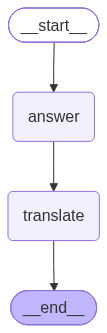

In [11]:
graph = parent_builder.compile()

graph

In [12]:
graph.invoke({'question': 'What is quantum physics'})

{'question': 'What is quantum physics',
 'answer_eng': 'Quantum physics, also known as quantum mechanics, is a branch of physics that studies the behavior of matter and energy at the smallest scales, such as atoms and subatomic particles. It aims to understand the fundamental nature of reality and the interactions between particles at the atomic and subatomic level.\n\nAt these scales, the classical laws of physics that govern the behavior of larger objects no longer apply, and strange, seemingly random phenomena occur. Quantum physics seeks to explain these phenomena and has led to a deeper understanding of the behavior of particles and systems at the atomic and subatomic level.\n\nSome key features of quantum physics include:\n\n1. **Wave-particle duality**: Quantum objects, such as electrons, can exhibit both wave-like and particle-like behavior depending on how they are observed.\n2. **Uncertainty principle**: It is impossible to know certain properties of a quantum object, such as